ROLL NUMBER: G25AIT1136 NAME: RIKIN PATEL

ASSIGNMENT-3 Sanskrit-English Sentence Embeddings

Assumption: - The given dataset is exported to the current directory (.)

In [13]:
###### Install Packages ######
%pip install torch pandas numpy scikit-learn matplotlib transformers sentencepiece seaborn tqdm

In [14]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE


In [15]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


Assuming dataset is imported to the current directory. The code below will print "MISSING" if any of the files not found, else will print "FOUND".

In [16]:
DATA_DIR = '.'

files = {
    'train_sa': os.path.join(DATA_DIR, 'train_sa_10000.csv'),
    'dev_sa': os.path.join(DATA_DIR, 'dev_sa_1000.csv'),
    'test_sa': os.path.join(DATA_DIR, 'test_sa_1000.csv'),
    'train_en': os.path.join(DATA_DIR, 'train_en_10000.csv'),
    'dev_en': os.path.join(DATA_DIR, 'dev_en_1000.csv'),
    'test_en': os.path.join(DATA_DIR, 'test_en_1000.csv'),
}

print(os.listdir(DATA_DIR))

for name, path in files.items():
    print(f'{name}:', 'FOUND' if os.path.exists(path) else f'MISSING -> {path}')

['.config', 'english_embeddings.npy', 'dev_en_1000.csv', 'test_en_1000.csv', 'test_sa_1000.csv', 'pairwise_cosine_scores.csv', 'train_sa_10000.csv', 'train_en_10000.csv', 'dev_sa_1000.csv', 'drive', 'sanskrit_embeddings.npy', 'sample_data']
train_sa: FOUND
dev_sa: FOUND
test_sa: FOUND
train_en: FOUND
dev_en: FOUND
test_en: FOUND


The Sanskrit files contain 'Source_id' and 'Sentence_sa' fields while English files contain 'Source_id' and "Sentence_en'. The code assumes the sentence pair alignment using 'Source_id' fields.

In [17]:

def load_parallel_split(sa_path, en_path, split_name):
    sa = pd.read_csv(sa_path)
    en = pd.read_csv(en_path)

    expected_sa = {'Source_id', 'Sentence_sa'}
    expected_en = {'Source_id', 'Sentence_en'}

    if not expected_sa.issubset(sa.columns):
        raise ValueError(f'{split_name} Sanskrit file must contain columns: {expected_sa}')
    if not expected_en.issubset(en.columns):
        raise ValueError(f'{split_name} English file must contain columns: {expected_en}')

    df = sa.merge(en, on='Source_id', how='inner')
    df = df.dropna(subset=['Sentence_sa', 'Sentence_en']).copy()
    df['Sentence_sa'] = df['Sentence_sa'].astype(str).str.strip()
    df['Sentence_en'] = df['Sentence_en'].astype(str).str.strip()
    df = df[(df['Sentence_sa'] != '') & (df['Sentence_en'] != '')].reset_index(drop=True)
    df['split'] = split_name
    return df

train_df = load_parallel_split(files['train_sa'], files['train_en'], 'train')
dev_df = load_parallel_split(files['dev_sa'], files['dev_en'], 'dev')
test_df = load_parallel_split(files['test_sa'], files['test_en'], 'test')

all_df = pd.concat([train_df, dev_df, test_df], ignore_index=True)

print('Train pairs:', len(train_df))
print('Dev pairs  :', len(dev_df))
print('Test pairs :', len(test_df))
print('Total pairs:', len(all_df))
all_df.head()

Train pairs: 10000
Dev pairs  : 1000
Test pairs : 1000
Total pairs: 12000


,Source_id,Sentence_sa,Sentence_en,split
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S.",train
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.,train
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two...",train
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.,train
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil...",train


**LaBSE**: - Preferred over MiniLM(described below) for Sanskrit-English similarity. LaBSE gives strong cross-languate alignment for many languages. The model is designed for language-agnostic sentence embeddings. [Ref: - https://research.google/blog/language-agnostic-bert-sentence-embedding/]

**MiniLM**: - Useful for lower dimensional and faster inference, It's a lightweight multilingual sentence model with good speed/quality tradeoff. [Ref: - https://milvus.io/ai-quick-reference/how-do-you-use-sentence-transformers-in-a-multilingual-setting-for-example-loading-a-multilingual-model-to-encode-sentences-in-different-languages]

From litrature, both LaBSE and MiniLM works good with PyTorch and do not require external API calls. LaBSE is good if safest sementic alignment is needed while MiniLM can be used when smaller embeddings and faster runtime is needed.


In [18]:

#MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
MODEL_NAME = 'sentence-transformers/LaBSE'


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

hidden_size = model.config.hidden_size
print('Model loaded:', MODEL_NAME)
print('Embedding dimension used:', hidden_size)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: sentence-transformers/LaBSE
Embedding dimension used: 768


**Mean Pooling**

In [19]:

def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    pooled = torch.sum(token_embeddings * input_mask_expanded, dim=1)
    pooled = pooled / torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
    return pooled



**Embedding Generation**

In [20]:
@torch.no_grad()
def encode_sentences(sentences, batch_size=32, max_length=128):
    embeddings = []

    for i in range(0, len(sentences), batch_size):
        batch_sentences = sentences[i:i+batch_size]
        encoded = tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}
        outputs = model(**encoded)
        batch_embeddings = mean_pooling(outputs, encoded['attention_mask'])
        batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)
        embeddings.append(batch_embeddings.cpu())

    return torch.cat(embeddings, dim=0)

sa_embeddings_torch = encode_sentences(all_df['Sentence_sa'].tolist(), batch_size=32)
en_embeddings_torch = encode_sentences(all_df['Sentence_en'].tolist(), batch_size=32)

print('Sanskrit embeddings shape:', tuple(sa_embeddings_torch.shape))
print('English embeddings shape:', tuple(en_embeddings_torch.shape))

Sanskrit embeddings shape: (12000, 768)
English embeddings shape: (12000, 768)


In [21]:

pairwise_cosine_scores = torch.sum(sa_embeddings_torch * en_embeddings_torch, dim=1)
avg_cosine_similarity = pairwise_cosine_scores.mean().item()

print('Embedding dimension:', sa_embeddings_torch.shape[1])
print('Average cosine similarity on Trained Sanskrit-English pairs:', round(avg_cosine_similarity, 6))

results_df = all_df[['Source_id', 'split']].copy()
results_df['cosine_similarity'] = pairwise_cosine_scores.cpu().numpy()
results_df.head()

Embedding dimension: 768
Average cosine similarity on Trained Sanskrit-English pairs: 0.745825


,Source_id,split,cosine_similarity
0,1,train,0.818362
1,2,train,0.745704
2,3,train,0.652781
3,4,train,0.699107
4,5,train,0.648652


This prints the Average Cosine Similarity for Dev, Test and Traine set.

In [22]:

split_scores = results_df.groupby('split', as_index=False)['cosine_similarity'].mean()
split_scores.columns = ['Split', 'Average Cosine Similarity']
split_scores

,Split,Average Cosine Similarity
0,dev,0.745599
1,test,0.746145
2,train,0.745816


The 2D t_SNE visualization for 100 sample Sanskrit-English pairs.

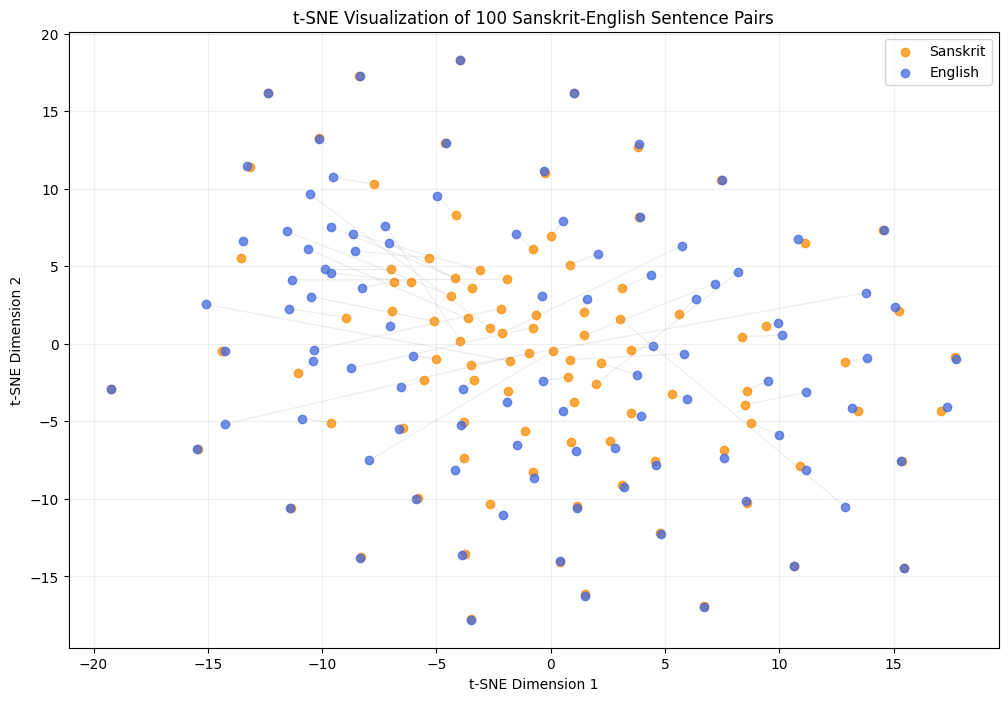

In [23]:

num_pairs = min(100, len(all_df))
sample_df = all_df.sample(num_pairs, random_state=SEED).reset_index(drop=True)

sample_sa_embeddings = encode_sentences(sample_df['Sentence_sa'].tolist(), batch_size=32).cpu().numpy()
sample_en_embeddings = encode_sentences(sample_df['Sentence_en'].tolist(), batch_size=32).cpu().numpy()

combined_embeddings = np.vstack([sample_sa_embeddings, sample_en_embeddings])
perplexity = min(30, max(5, num_pairs // 3))
tsne = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, init='pca', learning_rate='auto')
coords = tsne.fit_transform(combined_embeddings)

plt.figure(figsize=(12, 8))
sa_idx = np.arange(num_pairs)
en_idx = np.arange(num_pairs, 2 * num_pairs)

plt.scatter(coords[sa_idx, 0], coords[sa_idx, 1], c='darkorange', label='Sanskrit', alpha=0.75)
plt.scatter(coords[en_idx, 0], coords[en_idx, 1], c='royalblue', label='English', alpha=0.75)

for i in range(num_pairs):
    plt.plot(
        [coords[sa_idx[i], 0], coords[en_idx[i], 0]],
        [coords[sa_idx[i], 1], coords[en_idx[i], 1]],
        color='gray', alpha=0.15, linewidth=0.8
    )

plt.title(f't-SNE Visualization of {num_pairs} Sanskrit-English Sentence Pairs')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

**Result**: MiniLM, at 384 Embedding Dimentions, gives Average Cosine Similarity of ~0.54. While LaBSE, at 768 Embedding Dimentions, gives Average Cosine Similarity of ~0.74.

**Conclusion**: Although MiniLM is more compact at 384 dimensions, LaBSE achieves substantially higher average cosine similarity on Sanskrit-English pairs. Since the assignment prioritizes semantic similarity over dimensionality, LaBSE is the preferred model.

Saving the English Embeddings in 'english_embeddings.npy' and Sanskrit Embeddings in 'sanskrit_embeddings.npy' files. Also, the Pairwise Cosine Similarity Scores are saved in 'pairwise_cosine_scores.csv' for reference.

In [24]:

sa_embeddings_np = sa_embeddings_torch.cpu().numpy()
en_embeddings_np = en_embeddings_torch.cpu().numpy()

np.save('sanskrit_embeddings.npy', sa_embeddings_np)
np.save('english_embeddings.npy', en_embeddings_np)
results_df.to_csv('pairwise_cosine_scores.csv', index=False)

print('Saved: sanskrit_embeddings.npy')
print('Saved: english_embeddings.npy')
print('Saved: pairwise_cosine_scores.csv')

Saved: sanskrit_embeddings.npy
Saved: english_embeddings.npy
Saved: pairwise_cosine_scores.csv
